# ÉquiAlgo – Bias audit of the student-financing model

**Engineering & Computer Science Hackathon 2026 – audit report**

This notebook measures the bias in the decisions of the committee previously, and in the
production model. It also identifies the proxy variables, justifies our fairness metric,
and documents how we reconstructed the reference standard. Our mitigation is implemented in this notebook.

### Summary of our findings

| # | Finding | Evidence |
|---|---|---|
| 1 | The committee penalized a **~1.4 R points** to remote applicants | section 1.2, logistic model with bootstrap CI |
| 2 | A **second bias**: higher household income correlates with the increase of the grant probability | section 1.3 |
| 3 | `code_postal_3` and the region are the similar features; distance predicts it with AUC ≈ 1.0 | section 2.1 |
| 4 | Dropping the region moves the penalty to distance and hours worked | section 2.3 |
| 5 | Equal opportunity measured on committee labels is circular: fairlearn's EO constraint has nothing to fix | section 3.1 |
| 6 | The reference standard ranks on **R score + hours worked**; income, distance, regional bonuses and quotas are not part of it | section 3.2, 17 probe submissions |
| 7 | Under that merit both groups have the **same merit distribution**, so equal opportunity and demographic parity hold together | section 3.4 |
| 8 | Grant rate 40.0 % in both groups, EO gap ≈ −0.02 (baseline 0.27), 94.6 % agreement with the reference with the correct model| section 4 |

In [2]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split

import model_corrige as mc

# model_corrige selects the Agg backend for scripts; restore inline figures.
%matplotlib inline
pd.set_option('display.width', 160)
pd.set_option('display.precision', 3)

demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')
demandes['groupe'] = mc.groupe_region(demandes)
remote = (demandes['groupe'] == 'Remote').astype(int)
print(f'{len(demandes)} historical applications, {len(candidats)} candidates to score')

10000 historical applications, 4000 candidates to score


## 1. Measuring the bias

### 1.1 Grant rates by region

The committee gives 48 % of applicants from the two major centres and 27 % of
those from the three remote regions. The remote regions have a slightly lower
average R score, so the gap in R score alone does not prove bias.

In [3]:
par_region = demandes.groupby('region_administrative').agg(
    applicants=('decision_octroi', 'size'),
    grant_rate=('decision_octroi', 'mean'),
    r_score=('cote_r_equivalent', 'mean'),
    hours=('heures_travail_semaine', 'mean'),
    income=('revenu_familial_estime', 'mean'),
    distance_km=('distance_domicile_campus_km', 'mean'),
).sort_values('grant_rate')
display(par_region)
display(demandes.groupby('groupe')[['decision_octroi', 'cote_r_equivalent']].mean())

,applicants,grant_rate,r_score,hours,income,distance_km
region_administrative,,,,,,
Cote-Nord,1178,0.263,27.325,13.115,56056.296,225.934
Bas-Saint-Laurent,1293,0.269,27.296,12.954,56289.286,217.731
Gaspesie-Iles-de-la-Madeleine,1529,0.284,27.354,13.001,56576.151,221.152
Montreal,4001,0.483,27.988,8.984,75801.788,19.910
Capitale-Nationale,1999,0.484,27.984,8.949,76565.663,19.556


,decision_octroi,cote_r_equivalent
groupe,,
Center,0.484,27.987
Remote,0.273,27.327


### 1.2 At equal R score, remote applicants are granted far less

To investigate further, we compare applicants with the same R score. The result rejects the "lower R score" explanation.
Between R 26 and 32, the remote grant rate is 13 to 30 points below the centres.

,mean_Center,mean_Remote,size_Center,size_Remote,gap
r_bin,,,,,
"(0, 22]",0.000,0.000,126,155,0.000
"(22, 24]",0.002,0.000,410,381,0.002
"(24, 26]",0.030,0.008,996,757,0.022
"(26, 28]",0.241,0.067,1496,1063,0.174
"(28, 30]",0.709,0.408,1438,910,0.301
"(30, 32]",0.958,0.831,986,514,0.128
"(32, 34]",0.998,0.982,419,165,0.016
"(34, 41]",1.000,1.000,129,55,0.000


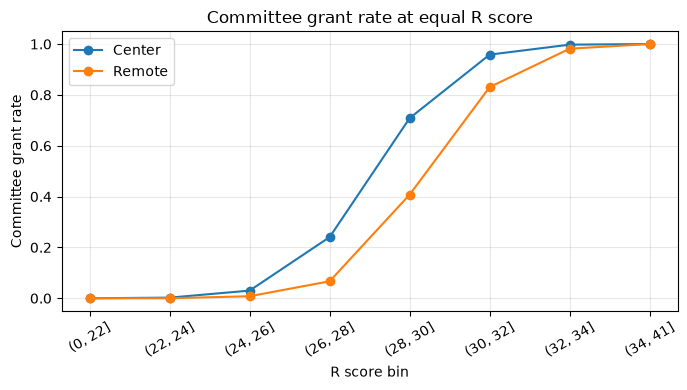

In [4]:
bins = [0, 22, 24, 26, 28, 30, 32, 34, 41]
demandes['r_bin'] = pd.cut(demandes['cote_r_equivalent'], bins)
par_bin = demandes.pivot_table(index='r_bin', columns='groupe', values='decision_octroi',
                               aggfunc=['mean', 'size'], observed=True)
par_bin.columns = [f'{a}_{b}' for a, b in par_bin.columns]
par_bin['gap'] = par_bin['mean_Center'] - par_bin['mean_Remote']
display(par_bin)

fig, ax = plt.subplots(figsize=(7, 4))
for g, couleur in [('Center', 'tab:blue'), ('Remote', 'tab:orange')]:
    ax.plot(range(len(par_bin)), par_bin[f'mean_{g}'], 'o-', color=couleur, label=g)
ax.set_xticks(range(len(par_bin)), [str(i) for i in par_bin.index], rotation=30)
ax.set_xlabel('R score bin'); ax.set_ylabel('Committee grant rate')
ax.set_title('Committee grant rate at equal R score'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### 1.3 Size of the penalty, in R score points

To determine the size of penalty that the committee used, we model the committee with a logistic regression on R score, log income, hours
worked and an explicit remote indicator. Program of study, first generation and
distance add nothing once these are known (section 2.3). Dividing each coefficient by the
R-score coefficient expresses it in R points, a unit that a committee member could understand. A bootstrap over applicants gives the confidence intervals.

In [5]:
modele = mc.ModeleComite().fit(demandes)
b_r = modele.coefs_['cote_r_equivalent']

rng = np.random.default_rng(0)
boot = []
for _ in range(200):
    echantillon = demandes.iloc[rng.integers(0, len(demandes), len(demandes))]
    m = mc.ModeleComite().fit(echantillon)
    boot.append({c: v / m.coefs_['cote_r_equivalent'] for c, v in m.coefs_.items()})
boot = pd.DataFrame(boot)

coefs = pd.DataFrame({
    'logit_coef': pd.Series(modele.coefs_),
    'in_R_points': pd.Series(modele.coefs_) / b_r,
    'ci_2.5%': boot.quantile(0.025),
    'ci_97.5%': boot.quantile(0.975),
})
display(coefs)
print(f'Regional penalty: {modele.penalite_points_r:.2f} R points '
      f'(95% CI {-boot["remote"].quantile(0.975):.2f} to {-boot["remote"].quantile(0.025):.2f})')

,logit_coef,in_R_points,ci_2.5%,ci_97.5%
cote_r_equivalent,1.384,1.000,1.000,1.000
log_revenu,1.781,1.287,1.159,1.386
heures_travail_semaine,0.201,0.145,0.131,0.159
remote,-1.942,-1.403,-1.535,-1.268


Regional penalty: 1.40 R points (95% CI 1.27 to 1.54)


A remote applicant needs about **1.4 more R points** than an otherwise identical
applicant from Montréal or Capitale-Nationale. The interval is far from zero.

### 1.4 Household income as another bias

The committee also favours richer households. That is surprising for a
scholarship and student-loan program, where the grant decision should be based on the need. The
effect is monotonic across income octiles. In section 3.2 we show that the reference
standard gives income no weight at all, so this effect is a second bias, separate
from the regional one. It also adds to the regional gap, because remote
households earn about $20k less on average.

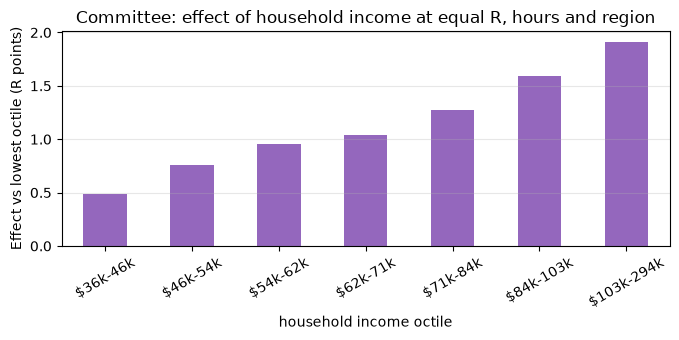

In [6]:
X = pd.DataFrame({
    'cote_r_equivalent': demandes['cote_r_equivalent'],
    'heures_travail_semaine': demandes['heures_travail_semaine'],
    'remote': remote,
})
octiles = pd.qcut(demandes['revenu_familial_estime'], 8)
X = X.join(pd.get_dummies(octiles, prefix='inc', drop_first=True).astype(int))
lr = LogisticRegression(penalty=None, max_iter=10_000).fit(X, demandes['decision_octroi'])
effets = pd.Series(lr.coef_[0], index=X.columns)
effet_revenu = effets.filter(like='inc_') / effets['cote_r_equivalent']
effet_revenu.index = [f'${i.left / 1000:.0f}k-{i.right / 1000:.0f}k' for i in octiles.cat.categories[1:]]

fig, ax = plt.subplots(figsize=(7, 3.5))
effet_revenu.plot.bar(ax=ax, color='tab:purple')
ax.set_ylabel('Effect vs lowest octile (R points)'); ax.set_xlabel('household income octile')
ax.set_title('Committee: effect of household income at equal R, hours and region')
ax.grid(alpha=0.3, axis='y'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 2. Proxy variables

### 2.1 Which columns reveal the region?

We know that opting out the `region_administrative` and `code_postal_3` cannot eliminate the hidden pattern of region in the data. `code_postal_3` maps one-to-one onto the region: each postal prefix belongs to
exactly one region. For the other columns, we train a classifier to predict
"remote" from each column alone and report the cross-validated AUC (0.5 = no
information, 1.0 = perfect proxy).

In [7]:
regions_par_cp = demandes.groupby('code_postal_3')['region_administrative'].nunique()
print(f'{len(regions_par_cp)} postal prefixes, max regions per prefix: {regions_par_cp.max()}')

num = ['distance_domicile_campus_km', 'heures_travail_semaine', 'revenu_familial_estime',
       'premiere_generation_universitaire', 'cote_r_equivalent']
auc = {c: cross_val_score(HistGradientBoostingClassifier(max_iter=100), demandes[[c]], remote,
                          cv=5, scoring='roc_auc').mean() for c in num}
auc['all numeric columns'] = cross_val_score(HistGradientBoostingClassifier(), demandes[num],
                                             remote, cv=5, scoring='roc_auc').mean()
auc['all numeric except distance'] = cross_val_score(
    HistGradientBoostingClassifier(), demandes[[c for c in num if c != 'distance_domicile_campus_km']],
    remote, cv=5, scoring='roc_auc').mean()
corr = {c: np.corrcoef(demandes[c], remote)[0, 1] for c in num}
display(pd.DataFrame({'AUC predicting remote': pd.Series(auc), 'correlation with remote': pd.Series(corr)}))

18 postal prefixes, max regions per prefix: 1


,AUC predicting remote,correlation with remote
all numeric columns,0.998,NaN
all numeric except distance,0.839,NaN
cote_r_equivalent,0.534,-0.108
distance_domicile_campus_km,0.998,0.816
heures_travail_semaine,0.805,0.521
premiere_generation_universitaire,0.590,0.186
revenu_familial_estime,0.681,-0.301


Distance is a near-perfect proxy (AUC ≈ 1.0). Even without distance, hours worked
and income recover the region with AUC ≈ 0.84. There is a pattern that remote students work about 4 more
hours a week, and their households earn less.

### 2.2 Dropping the region does not remove the bias

This reproduces the trap from the baseline notebook: the production random forest
retrained without `region_administrative`, then also without `code_postal_3`.

In [8]:
train, test = train_test_split(demandes.drop(columns=['groupe', 'r_bin']), test_size=0.3,
                               random_state=42, stratify=demandes['decision_octroi'])
groupe_test = mc.groupe_region(test)
cat = ['programme_etudes', 'region_administrative', 'code_postal_3']
Xtr = pd.get_dummies(train.drop(columns=['id_candidat', 'decision_octroi']), columns=cat)
Xte = pd.get_dummies(test.drop(columns=['id_candidat', 'decision_octroi']), columns=cat).reindex(columns=Xtr.columns, fill_value=0)

lignes = []
for etiquette, exclues in [('all features', ()), ('without region', ('region_administrative_',)),
                           ('without region and postal code', ('region_administrative_', 'code_postal_3_'))]:
    garder = [c for c in Xtr.columns if not c.startswith(exclues)] if exclues else list(Xtr.columns)
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
    p = rf.fit(Xtr[garder], train['decision_octroi']).predict(Xte[garder])
    lignes.append({'model': etiquette, 'rate_Center': p[groupe_test == 'Center'].mean(),
                   'rate_Remote': p[groupe_test == 'Remote'].mean(),
                   'parity_gap': p[groupe_test == 'Center'].mean() - p[groupe_test == 'Remote'].mean()})
display(pd.DataFrame(lignes).set_index('model'))

,rate_Center,rate_Remote,parity_gap
model,,,
all features,0.459,0.271,0.188
without region,0.458,0.278,0.180
without region and postal code,0.465,0.292,0.173


### 2.3 Where the penalty goes when the region is removed

When the committee model is fit **without** the remote indicator, the penalty
does not disappear. It is redistributed onto the proxies:

* distance gets a large negative weight, about −0.8 R points for a typical remote
  applicant 220 km from campus;
* the weight on hours worked falls by about 30 %, because hours are higher in the
  remote regions;
* income gains weight.

This is why our correction **keeps** the remote indicator during training: the
penalty is absorbed by one interpretable coefficient for the remote indicator, after that we set it to zero
when scoring.

In [9]:
Xc = pd.DataFrame({
    'cote_r_equivalent': demandes['cote_r_equivalent'],
    'log_income': np.log(demandes['revenu_familial_estime']),
    'heures_travail_semaine': demandes['heures_travail_semaine'],
    'distance_100km': demandes['distance_domicile_campus_km'] / 100,
})
fuite = {}
for nom, XX in [('with remote indicator', Xc.assign(remote=remote)), ('without remote indicator', Xc)]:
    lr = LogisticRegression(penalty=None, max_iter=10_000).fit(XX, demandes['decision_octroi'])
    fuite[nom] = pd.Series(lr.coef_[0] / lr.coef_[0][0], index=XX.columns)
display(pd.DataFrame(fuite).rename_axis('coefficient, in R points'))

,with remote indicator,without remote indicator
"coefficient, in R points",,
cote_r_equivalent,1.000,1.000
distance_100km,0.078,-0.375
heures_travail_semaine,0.146,0.104
log_income,1.284,1.472
remote,-1.563,NaN


## 3. Fairness metrics

### 3.1 Equal opportunity on committee labels is circular

The baseline notebook computes true positive rates against `decision_octroi`, the
labels of the committee under audit. A model that copies the committee looks
fair by that measure. Below, a logistic regression without the region and
fairlearn's mitigations are all scored **against the committee labels**: the TPR
of the two groups is already nearly equal. An `ExponentiatedGradient` with a TPR
parity constraint therefore returns the same model at every bound. The constraint
has nothing to correct, because the bias is in the labels themselves.

In [10]:
sorties = mc.comparaison_fairlearn(train, test)
y_hist = test['decision_octroi'].to_numpy()
tpr_hist = pd.DataFrame({
    nom: {'TPR_Center (committee labels)': p[(groupe_test == 'Center') & (y_hist == 1)].mean(),
          'TPR_Remote (committee labels)': p[(groupe_test == 'Remote') & (y_hist == 1)].mean(),
          'grant_rate_Remote': p[groupe_test == 'Remote'].mean()}
    for nom, p in ((k, np.asarray(v)) for k, v in sorties.items())
}).T
display(tpr_hist)

,TPR_Center (committee labels),TPR_Remote (committee labels),grant_rate_Remote
LR sans region,0.849,0.838,0.309
ThresholdOptimizer TPR,0.873,0.876,0.334
ThresholdOptimizer DP,0.756,0.953,0.409
ExpGrad TPR 0.02,0.842,0.829,0.311
ExpGrad DP 0.02,0.788,0.929,0.379
ExpGrad TPR 0.05,0.842,0.829,0.311
ExpGrad DP 0.05,0.801,0.929,0.365
ExpGrad TPR 0.10,0.842,0.829,0.311
ExpGrad DP 0.10,0.842,0.850,0.319


We therefore need a notion of who deserves a grant that does not come from the
committee. The challenge's reference standard is hidden, but HxBuddy reports the
accuracy of a submitted prediction file against it. We used that as an
experimental instrument.

### 3.2 Reconstructing the reference standard from 17 probe submissions

Each probe changes one element of the scoring rule, so a change in accuracy
can be attributed to that element. All probes respect the 36-44 % budget. Every
file is regenerated below from its configuration and checked against the file we
submitted.

In [11]:
final = mc.ModeleComite().fit(demandes)
b_r_final = final.coefs_['cote_r_equivalent']
g_cand = mc.groupe_region(candidats)
base = final.score(candidats, lam=1.0) / b_r_final  # R + hours merit, in R points

def par_groupe(score, colonne):
    # Top 40% within each value of `colonne` (quota probes).
    p = np.zeros(len(candidats), dtype=int)
    for _, idx in candidats.groupby(colonne).indices.items():
        p[idx] = mc.allouer(score[idx])
    return p

log_rev = np.log(candidats['revenu_familial_estime']); log_rev = (log_rev - log_rev.mean()).to_numpy()
dist = (candidats['distance_domicile_campus_km'] - candidats['distance_domicile_campus_km'].mean()).to_numpy()
rem = (g_cand == 'Remote').astype(float)

sondes = [
    # round, file, description, HxBuddy accuracy (%), predictions
    (1, 'pred_r_heures_lam1', 'R + hours, penalty removed', 94.63, mc.allouer(final.score(candidats, 1.0, 'r_heures'))),
    (1, 'pred_complet_lam1', '+ income (committee weight)', 92.53, mc.allouer(final.score(candidats, 1.0, 'complet'))),
    (1, 'pred_r_seul_lam1', 'R only', 92.28, mc.allouer(final.score(candidats, 1.0, 'r_seul'))),
    (1, 'pred_besoin_lam1', '- income (need-based)', 92.08, mc.allouer(final.score(candidats, 1.0, 'besoin'))),
    (1, 'pred_complet_lam0.5', 'committee, half the penalty removed', 91.48, mc.allouer(final.score(candidats, 0.5, 'complet'))),
    (1, 'pred_complet_lam0', 'committee as is', 88.68, mc.allouer(final.score(candidats, 0.0, 'complet'))),
    (2, 'sonde_poids_heures0.1', 'hours weight 0.10 R pt/h', 94.18, mc.allouer(final.score(candidats, 1.0, poids_heures=0.10))),
    (2, 'sonde_poids_heures0.2', 'hours weight 0.20 R pt/h', 94.03, mc.allouer(final.score(candidats, 1.0, poids_heures=0.20))),
    (2, 'sonde_taux0.38', 'grant rate 38%', 94.38, mc.allouer(final.score(candidats, 1.0), 0.38)),
    (2, 'sonde_taux0.42', 'grant rate 42%', 94.48, mc.allouer(final.score(candidats, 1.0), 0.42)),
    (2, 'sonde_bonus_pg0.5', 'first-generation bonus 0.5 R pt', 93.63, mc.allouer(final.score(candidats, 1.0, bonus_pg=0.5))),
    (3, 'round3/sonde_remote_bonus0.35', 'remote bonus +0.35 R pt', 94.18, mc.allouer(base + 0.35 * rem)),
    (3, 'round3/sonde_remote_bonus0.7', 'remote bonus +0.7 R pt', 93.03, mc.allouer(base + 0.7 * rem)),
    (3, 'round3/sonde_distance_plus0.002', 'distance bonus', 93.68, mc.allouer(base + 0.002 * dist)),
    (3, 'round3/sonde_revenu_moins0.3', 'small need-based income term', 94.23, mc.allouer(base - 0.3 * log_rev)),
    (3, 'round3/sonde_revenu_plus0.3', 'small positive income term', np.nan, mc.allouer(base + 0.3 * log_rev)),
    (3, 'round3/sonde_quota_programme', '40% quota per program', 94.45, par_groupe(base, 'programme_etudes')),
    (3, 'round3/sonde_quota_region', '40% quota per region', 94.65, par_groupe(base, 'region_administrative')),
]

meilleur = sondes[0][4]
lignes = []
for tour, fichier, description, acc, p in sondes:
    soumis = pd.read_csv(mc.RESULTATS / 'hxbuddy' / f'{fichier}.csv')['decision_octroi'].to_numpy()
    lignes.append({'round': tour, 'probe': description, 'HxBuddy accuracy': acc,
                   'rows changed vs best': int((p != meilleur).sum()),
                   'rate_Center': p[g_cand == 'Center'].mean(), 'rate_Remote': p[g_cand == 'Remote'].mean(),
                   'reproduced': bool((p == soumis).all())})
journal = pd.DataFrame(lignes)
display(journal)
print(f"{journal['reproduced'].sum()}/{len(journal)} probe files regenerated identically to the files in resultats/hxbuddy/")

,round,probe,HxBuddy accuracy,rows changed vs best,rate_Center,rate_Remote,reproduced
0,1,"R + hours, penalty removed",94.63,0,0.400,0.400,True
1,1,+ income (committee weight),92.53,244,0.422,0.368,True
2,1,R only,92.28,222,0.428,0.359,True
3,1,- income (need-based),92.08,224,0.379,0.430,True
4,1,"committee, half the penalty removed",91.48,304,0.453,0.322,True
5,1,committee as is,88.68,424,0.485,0.276,True
6,2,hours weight 0.10 R pt/h,94.18,84,0.411,0.385,True
7,2,hours weight 0.20 R pt/h,94.03,88,0.386,0.421,True
8,2,grant rate 38%,94.38,80,0.379,0.382,True
9,2,grant rate 42%,94.48,80,0.419,0.421,True


18/18 probe files regenerated identically to the files in resultats/hxbuddy/


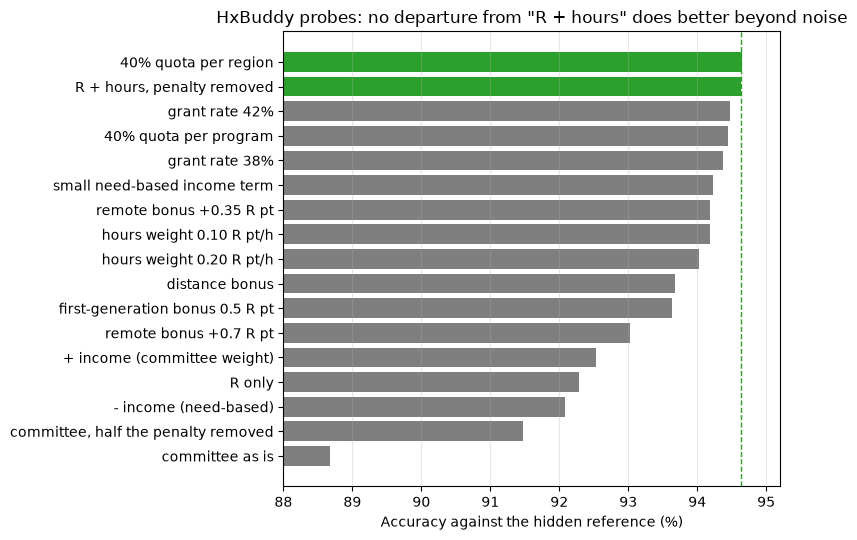

In [12]:
j = journal.dropna(subset=['HxBuddy accuracy']).sort_values('HxBuddy accuracy')
fig, ax = plt.subplots(figsize=(8, 5.5))
couleurs = ['tab:green' if a >= 94.6 else 'tab:gray' for a in j['HxBuddy accuracy']]
ax.barh(j['probe'], j['HxBuddy accuracy'], color=couleurs)
ax.axvline(94.63, color='tab:green', ls='--', lw=1)
ax.set_xlim(88, 95.2); ax.set_xlabel('Accuracy against the hidden reference (%)')
ax.set_title('HxBuddy probes: no departure from "R + hours" does better beyond noise')
ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()

What the probes establish:

* **Merit = R score + hours worked**, at the committee's own weight of about 0.145
  R points per hour. Lower (0.10) and higher (0.20) weights both score lower.
* **Income is not merit.** Adding it in either direction lowers accuracy, at the
  committee's weight and at a small weight. The committee's income preference
  (§1.4) is a bias.
* **Removing the penalty fully is right (λ = 1)**, and adding more is wrong.
  Remote bonuses of +0.35 and +0.7 R points both score lower. The reference treats
  the 0.7-point R difference between groups as real, not as measurement bias.
* **No quotas, no distance or first-generation bonus.** The per-region quota ties
  with the best submission, a difference of 1 applicant out of 4,000.
* **The reference grants about 40 %.** At 38 % and 42 % accuracy drops.
* **The remaining ~5.4 % disagreement is noise.** Moving the threshold by 80
  applicants costs only 10 correct decisions, so the reference is close to a coin
  flip near the threshold.

### 3.3 Validating the holdout pseudo-reference

To evaluate on the historical holdout we need labels. We draw **pseudo-reference
labels** from the committee model with the penalty removed and merit = R + hours.
They are an assumption, not ground truth, and they favour our own method by
construction. One independent check: measured against these labels, the
production random forest has an EO gap of about 0.28, close to the **0.270**
reported by the organisers against the real reference.

In [13]:
modele_train = mc.ModeleComite().fit(train)
reglage = {'merite': 'r_heures'}
y_ref = mc.etiquettes_equitables(modele_train, test, reglage)
merite_test = modele_train.score(test, lam=1.0, **reglage)
p_rf = mc.rf_production(train, test)
r = mc.mesurer(p_rf, y_ref, y_hist, groupe_test, merite_test)
print(f"Production RF: TPR Center {r['tpr_Center']:.3f}, TPR Remote {r['tpr_Remote']:.3f}, "
      f"EO gap {r['ecart_eo']:.3f}  (organisers' figure: 0.270)")

Production RF: TPR Center 0.855, TPR Remote 0.573, EO gap 0.282  (organisers' figure: 0.270)


### 3.4 Equal opportunity or demographic parity?

* **Demographic parity (DP):** both groups receive grants at the same rate.
* **Equal opportunity (EO):** among applicants who deserve a grant, both groups
  have the same chance of receiving it, i.e. equal true positive rates.

The two conflict only when the groups differ in their share of deserving
applicants. The histogram below shows merit by group. With R alone, remote
applicants look weaker. With the merit the reference actually uses (R + hours),
the two distributions coincide: remote students have a slightly lower R score
but work about 4 more hours a week.

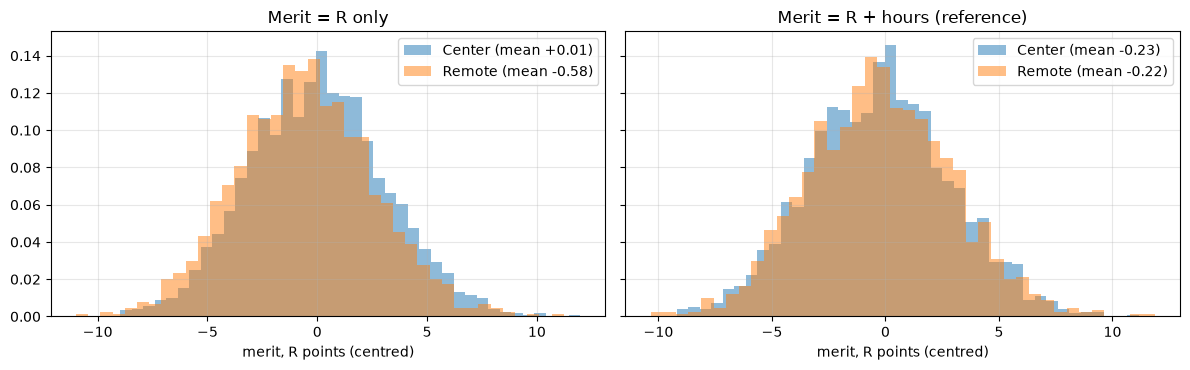

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (titre, merite) in zip(axes, [('Merit = R only', 'r_seul'), ('Merit = R + hours (reference)', 'r_heures')]):
    s = final.score(candidats, lam=1.0, merite=merite) / b_r_final
    for g, couleur in [('Center', 'tab:blue'), ('Remote', 'tab:orange')]:
        ax.hist(s[g_cand == g], bins=40, density=True, alpha=0.5, color=couleur,
                label=f'{g} (mean {s[g_cand == g].mean():+.2f})')
    ax.set_title(titre); ax.set_xlabel('merit, R points (centred)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

To see where the two metrics diverge, we compare a single threshold (EO-style)
with a per-group 40 % quota (DP) on the holdout, in two worlds: the hypothetical
one where merit is R alone, and the real one where merit is R + hours.

In [15]:
def dp_alloc(score, groupe, taux=0.40):
    p = np.zeros(len(score), dtype=int)
    for g in np.unique(groupe):
        p[groupe == g] = mc.allouer(score[groupe == g], taux)
    return p

r_test = test['cote_r_equivalent'].to_numpy()
mondes = {
    'R only (hypothetical)': (mc.etiquettes_equitables(modele_train, test, {'merite': 'r_seul'}), r_test),
    'R + hours (reference)': (y_ref, merite_test),
}
s_comite = modele_train.score(test, lam=0.0, merite='complet')
lignes = []
for monde, (y_monde, s_monde) in mondes.items():
    politiques = {'single threshold on merit (EO)': mc.allouer(s_monde),
                  'per-group quota on merit (DP)': dp_alloc(s_monde, groupe_test)}
    if monde.startswith('R + hours'):
        politiques['per-group quota on committee score (DP)'] = dp_alloc(s_comite, groupe_test)
        politiques['per-group quota on R only (DP)'] = dp_alloc(r_test, groupe_test)
    for nom, p in politiques.items():
        m = mc.mesurer(p, y_monde, y_hist, groupe_test, s_monde)
        lignes.append({'world': monde, 'policy': nom, 'rate_Center': m['taux_Center'],
                       'rate_Remote': m['taux_Remote'], 'EO_gap': m['ecart_eo'],
                       'agreement': m['accord_reference']})
display(pd.DataFrame(lignes).set_index(['world', 'policy']))

p_eo = mc.allouer(final.score(candidats, lam=1.0))
p_dp = dp_alloc(final.score(candidats, lam=1.0), g_cand)
print(f'Candidates: the DP version differs from our submission on {int((p_eo != p_dp).sum())} of 4000 applicants')

rate_Center  rate_Remote  EO_gap  agreement
world                 policy                                                                              
R only (hypothetical) single threshold on merit (EO)                 0.429        0.358   0.005      0.870
                      per-group quota on merit (DP)                  0.400        0.400  -0.096      0.868
R + hours (reference) single threshold on merit (EO)                 0.399        0.401  -0.023      0.870
                      per-group quota on merit (DP)                  0.400        0.400  -0.023      0.870
                      per-group quota on committee score (DP)        0.400        0.400  -0.025      0.862
                      per-group quota on R only (DP)                 0.400        0.400  -0.019      0.861

Candidates: the DP version differs from our submission on 0 of 4000 applicants


**Our choice: equal opportunity.**

1. **A scholarship rewards merit.** EO states the property we want to protect:
   a deserving applicant has the same chance wherever they live.
2. **DP can require region-specific thresholds.** In the R-only world, forcing
   40/40 grants remote applicants with less merit than refused centre applicants
   (EO gap −0.10). Two applicants with the same merit would get different
   decisions because of where they live, which is exactly the committee's fault.
3. **DP can be met without fixing anything.** A 40/40 quota on the committee's
   own score satisfies DP but keeps the income bias inside each group, and agrees
   less with the reference.
4. **EO is the metric the institution is accountable for** in this audit.

**What happens in this data.** With the correct merit, the groups are equally
deserving, so the single threshold also yields 40/40: the DP version of our model
changes zero decisions. We optimise EO, and DP follows. The 21-point gap in
the committee's grant rates is bias, not a difference in merit.

**What we cannot settle.** EO requires knowing who deserves a grant, which we
know only through the reference probes. If the remote regions' lower R scores
reflected unequal schooling rather than merit, a compensating bonus could be
justified. The reference does not apply one (section 3.2), and adopting one would be a
policy decision for the institution, not a modelling choice.

## 4. Result of the correction

`model_corrige.py` fits the committee model with the remote indicator, scores
applicants with a fraction λ of the penalty removed, and grants the top 40 %.
Sweeping λ gives the fairness / utility trade-off on the holdout.

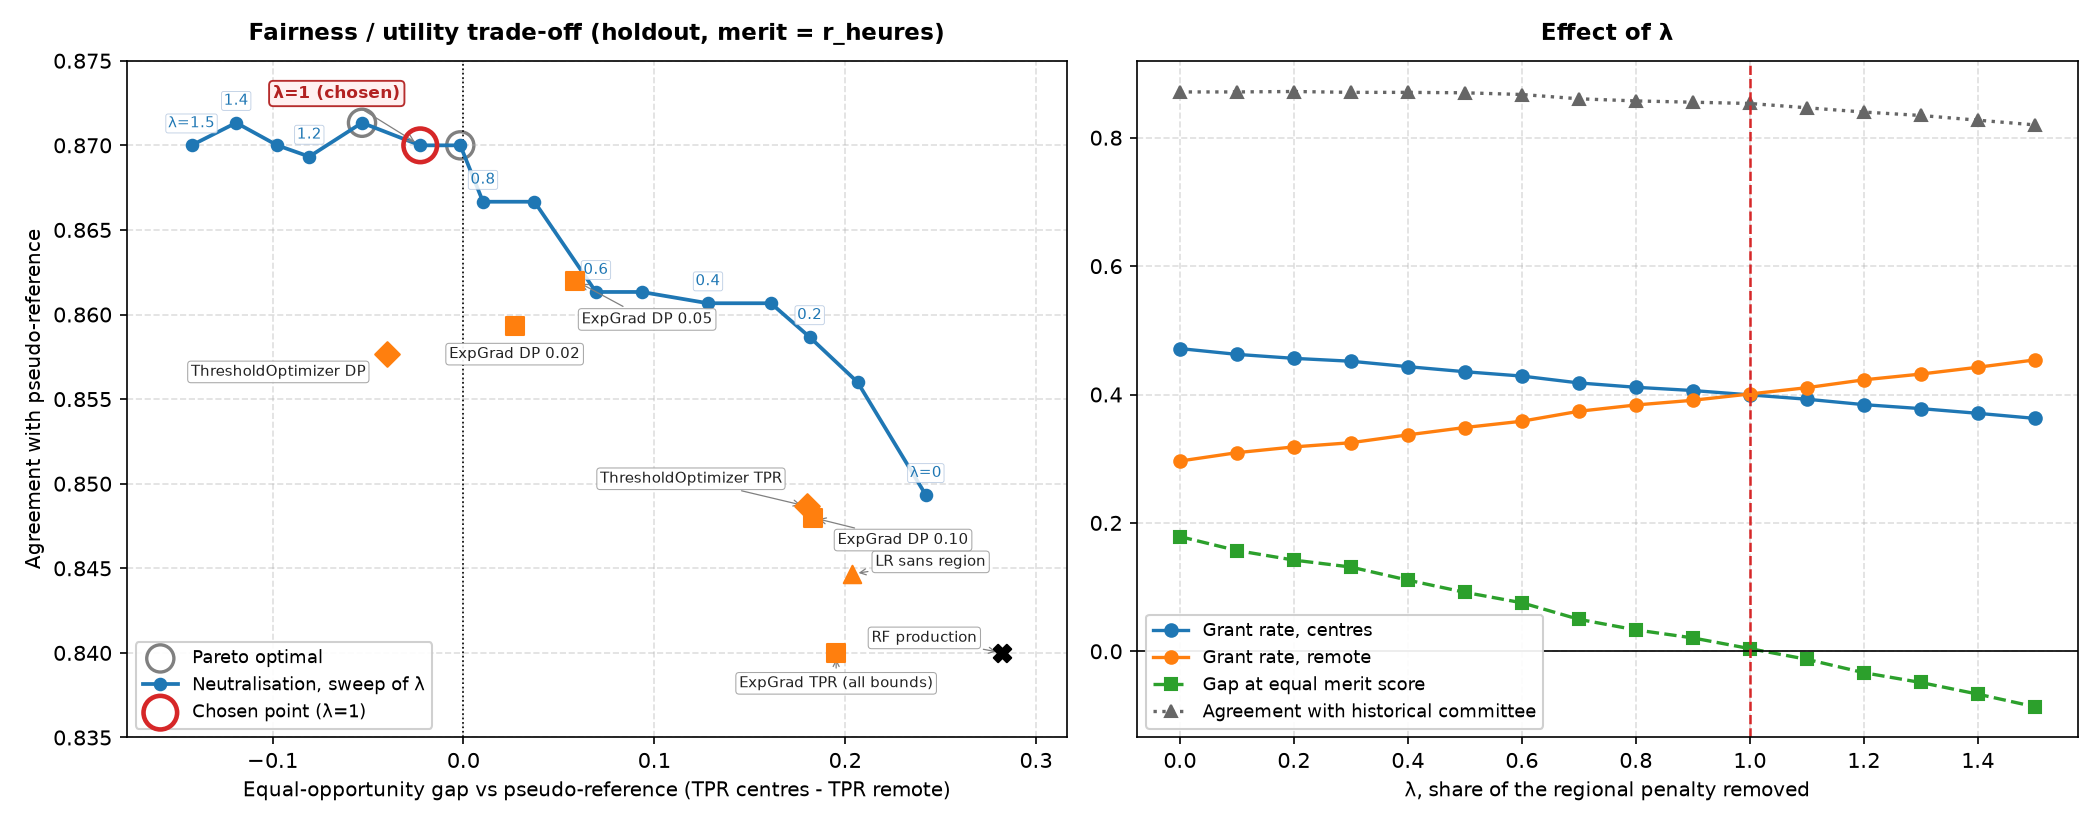

,taux_Center,taux_Remote,ecart_parite,ecart_eo,ecart_conditionnel_merite,accord_reference,accord_comite
lam,,,,,,,
0.0,0.472,0.296,0.175,0.242,0.179,0.849,0.871
0.5,0.435,0.349,0.087,0.093,0.092,0.861,0.870
0.9,0.406,0.391,0.015,-0.002,0.021,0.870,0.855
1.0,0.399,0.401,-0.001,-0.023,0.004,0.870,0.853
1.2,0.384,0.423,-0.039,-0.081,-0.033,0.869,0.840


In [16]:
lignes = []
for lam in mc.LAMBDAS:
    p = mc.allouer(modele_train.score(test, lam=lam, **reglage))
    lignes.append({'lam': lam, **mc.mesurer(p, y_ref, y_hist, groupe_test, merite_test)})
balayage = pd.DataFrame(lignes)
autres = pd.DataFrame({nom: mc.mesurer(np.asarray(p), y_ref, y_hist, groupe_test, merite_test)
                       for nom, p in {'RF production': p_rf, **sorties}.items()}).T
import importlib
importlib.reload(mc)
mc.tracer(balayage, autres, 1.0, 'r_heures', mc.RESULTATS / 'pareto_front.png')
display(Image(filename=str(mc.RESULTATS / 'pareto_front.png')))

colonnes = ['taux_Center', 'taux_Remote', 'ecart_parite', 'ecart_eo', 'ecart_conditionnel_merite',
            'accord_reference', 'accord_comite']
display(balayage.set_index('lam').loc[[0.0, 0.5, 0.9, 1.0, 1.2], colonnes])

* **λ = 0** reproduces the committee: EO gap ≈ 0.24 on the holdout.
* Accuracy against the reference rises as the penalty is removed, peaks around
  λ = 0.9–1.0, then falls as we over-correct. Fairness and utility are not in
  tension until λ = 1. The cost is only in agreement with the historical
  committee, which is the thing under audit.
* We choose **λ = 1**: the whole penalty removed, nothing more. It is the
  simplest rule to explain ("region plays no role") and the one HxBuddy confirms.
  λ = 0.9 has a marginally smaller EO gap on the holdout, but the difference is
  within the noise of pseudo-labels.
* The gap at equal merit (`ecart_conditionnel_merite`), which needs no labels,
  falls from 0.18 to 0.00.

Final decisions on the 4,000 candidates:

In [17]:
soumission = pd.read_csv('predictions.csv')
assert (soumission['id_candidat'] == candidats['id_candidat']).all()
assert (soumission['decision_octroi'].to_numpy() == p_eo).all()
resume = candidats.assign(decision=soumission['decision_octroi'], groupe=g_cand)
display(pd.concat([
    resume.groupby('groupe')['decision'].agg(['size', 'mean']),
    resume.groupby('region_administrative')['decision'].agg(['size', 'mean']),
]).rename(columns={'size': 'applicants', 'mean': 'grant_rate'}))
print(f"Overall grant rate: {resume['decision'].mean():.1%} (budget 36-44%)")

,applicants,grant_rate
Center,2372,0.400
Remote,1628,0.400
Bas-Saint-Laurent,504,0.383
Capitale-Nationale,821,0.397
Cote-Nord,491,0.397
Gaspesie-Iles-de-la-Madeleine,633,0.415
Montreal,1551,0.402


Overall grant rate: 40.0% (budget 36-44%)


## 5. Limitations

* **Holdout evaluation is partly circular.** The pseudo-reference is built from
  our own neutralised model. Our independent evidence is the 17 HxBuddy probes,
  the production model's pseudo-EO gap matching the official 0.270, and the
  label-free gap at equal merit.
* **HxBuddy reports accuracy only.** Our EO gap against the real reference
  (≈ −0.02, about 90 % of the baseline gap closed) is an estimate.
* **Hours worked is itself a regional proxy** (AUC 0.81). We keep it because the
  reference uses it and because it raises remote applicants' chances: it
  measures need and effort, not region. In production, its use should be
  reviewed with the ethics committee.
* **Two groups, one attribute.** We audited centres vs remote regions as defined
  in the brief. Intersections (e.g. remote × first generation) and other
  attributes were not audited and belong in the monitoring plan.
* **The data are synthetic**, and the committee's behaviour is stable across the
  dataset. A real deployment must re-estimate the penalty over time, since
  committee practice and applicant populations drift.